In [1]:
from ultralytics import YOLO

In [2]:
import torch

In [12]:
import torch
import torch.nn as nn

class FeatureExtractor:
    def __init__(self, model, layer_names):
        self.model = model
        self.layer_names = layer_names
        self.features = {}
        self.hooks = []
        
        # Register hooks
        for name, module in model.named_modules():
            if name in layer_names:
                hook = module.register_forward_hook(self.get_activation(name))
                self.hooks.append(hook)
    
    def get_activation(self, name):
        def hook(module, input, output):
            self.features[name] = output.detach()
        return hook
    
    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()



model =YOLO("../checkpoints/yolo11n.pt")
backbone = YOLO("../checkpoints/yolo11n.pt")
backbone.model.model = backbone.model.model[:17]
extractor = FeatureExtractor(backbone.model, ['model.16.cv2', 'model.13.cv2', 'model.10.cv2'])  # example layer names

# Forward pass
x = torch.randn(1, 3, 640, 640)
output = backbone.model(x)
features = extractor.features  # Dictionary with extracted features

# Clean up
extractor.remove_hooks()

In [3]:
model =YOLO("../checkpoints/yolo11n.pt")

In [5]:
image = "../data/group_test/office3.jpg"
out = model(image)


image 1/1 e:\synclabs\edgeface\notebooks\..\data\group_test\office3.jpg: 448x640 8 persons, 2 ties, 2 bottles, 1 cup, 1 potted plant, 3 tvs, 50.9ms
Speed: 9.3ms preprocess, 50.9ms inference, 226.1ms postprocess per image at shape (1, 3, 448, 640)


In [7]:
out[0].names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [13]:
features

{'model.10.cv2': tensor([[[[-0.0141, -0.0245, -0.0246,  ..., -0.0248, -0.0174, -0.0177],
           [-0.0168, -0.0267, -0.0199,  ..., -0.0299, -0.0263, -0.0223],
           [-0.0069, -0.0274, -0.0254,  ..., -0.0281, -0.0244, -0.0319],
           ...,
           [-0.0349, -0.0232, -0.0215,  ..., -0.0242, -0.0183, -0.0266],
           [-0.0324, -0.0272, -0.0263,  ..., -0.0213, -0.0201, -0.0332],
           [-0.0251, -0.0354, -0.0292,  ..., -0.0259, -0.0246, -0.0220]],
 
          [[ 0.2872,  0.4284,  0.4179,  ...,  0.2388,  0.2702,  0.3250],
           [ 0.2246,  0.1691,  0.0059,  ...,  0.0866,  0.1026,  0.0937],
           [ 0.0088,  0.1116,  0.0496,  ...,  0.1761, -0.0548,  0.0856],
           ...,
           [ 0.3980,  0.4424,  0.4393,  ...,  0.4607,  0.4724,  0.5745],
           [ 0.5019,  0.5038,  0.3503,  ...,  0.6065,  0.4938,  0.3907],
           [ 0.9312,  0.8669,  0.7704,  ...,  0.9138,  0.8368,  0.9733]],
 
          [[-0.2130, -0.2701, -0.2458,  ..., -0.2731, -0.1942, -0.2135

In [8]:
print(backbone.model.model)

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C3k2(
    (cv1): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
       

In [16]:
for name, module in model.model.named_modules():
        print(f"{name}, {module}")

, DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
 

In [1]:
from ultralytics import YOLO
import torch
import torch.nn as nn

In [2]:
class BackboneRunner(nn.Module):
    def __init__(self, full_model: nn.Module, end_idx: int = 16, keep_indices=(10,13,16)):
        super().__init__()
        self.full = full_model          # e.g., backbone = YOLO(...).model
        self.layers = full_model.model  # nn.ModuleList of layers
        self.end_idx = end_idx
        self.keep = set(keep_indices)

    
    def forward(self, x):
        y = {}          # map: layer_index -> tensor output
        last = x
        for i, m in enumerate(self.layers):
            # stop at end_idx and return what we need
            if i > self.end_idx:
                break

            f = m.f if isinstance(m.f, (list, tuple)) else [m.f]
            if f == [-1]:
                inp = last
            else:
                # gather inputs from previous indices
                inputs = [y[j] if j in y else last for j in f]
                inp = inputs if len(inputs) > 1 else inputs[0]

            out = m(inp)
            y[i] = out
            last = out

        # seed dict for the head: include last backbone output and any indices the head will reference
        seed = {i: y[i] for i in self.keep if i in y}
        seed['last'] = last  # what -1 means at the split boundary
        return seed


In [3]:
yolo = YOLO("../checkpoints/yolo11n.pt")
full = yolo.model
backbone = BackboneRunner(full_model=full, end_idx=16, keep_indices=(10,13,16))

In [4]:
class HeadRunner(nn.Module):
    def __init__(self, full_model: nn.Module, start_idx: int = 17):
        super().__init__()
        self.full = full_model
        self.layers = full_model.model
        self.start_idx = start_idx

    def forward(self, seed: dict):
        y = {}  # outputs created in head (indices >= start_idx)
        last = seed['last']  # what -1 refers to at the boundary

        for i in range(self.start_idx, len(self.layers)):
            m = self.layers[i]
            f = m.f if isinstance(m.f, (list, tuple)) else [m.f]

            if f == [-1]:
                inp = last
            else:
                inputs = []
                for j in f:
                    if j >= self.start_idx:
                        # comes from a head-produced output
                        inputs.append(y[j])
                    elif j == -1:
                        inputs.append(last)
                    else:
                        # comes from the backbone; must be present in seed (e.g., 10, 13, 16)
                        if j not in seed:
                            raise KeyError(
                                f"Head layer {i} needs feature from layer {j}, "
                                f"but it wasn't provided in seed."
                            )
                        inputs.append(seed[j])
                inp = inputs if len(inputs) > 1 else inputs[0]

            out = m(inp)
            y[i] = out
            last = out

        return last  # or return a dict of what you need (e.g., logits, boxes, masks)


In [5]:
from PIL import Image
import numpy as np

In [6]:
img = Image.open("../data/group_test/office3.jpg")
img = np.array(img)
img = np.transpose(img,(2,0,1))

In [7]:
img = torch.tensor(img[None])

In [8]:
img = ((img/255 - 0.5)/0.5)

In [9]:
x = torch.randn(1, 3, 380, 570)  # example input
seed = backbone(img)

In [10]:
head_model = HeadRunner(full_model=full, start_idx=17)

In [11]:
pose_model = YOLO("../checkpoints/yolo11n-pose.pt")

In [12]:
head_pose = HeadRunner(full_model=pose_model.model, start_idx=17)

In [13]:
final_out = head_model(seed)

In [14]:
pose_out = head_pose(seed)

In [16]:
import torch

import torch

def non_max_suppression_torch(boxes, scores, iou_threshold):
    """
    Performs Non-Maximum Suppression (NMS) on a set of bounding boxes in
    (x_center, y_center, width, height) format.

    Args:
        boxes (torch.Tensor): Bounding boxes in (x_center, y_center, width, height)
                              format. Shape: (N, 4)
        scores (torch.Tensor): Confidence scores for each box. Shape: (N,)
        iou_threshold (float): IoU threshold for suppressing boxes.

    Returns:
        List[int]: Indices of the boxes to keep.
    """
    # Ensure inputs are tensors and on the same device
    if not isinstance(boxes, torch.Tensor):
        boxes = torch.tensor(boxes)
    if not isinstance(scores, torch.Tensor):
        scores = torch.tensor(scores)

    # If no boxes, return an empty list
    if boxes.numel() == 0:
        return []

    # 1. Convert (x_center, y_center, width, height) to (x_min, y_min, x_max, y_max)
    x_center, y_center, width, height = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    
    x_min = x_center - width / 2
    y_min = y_center - height / 2
    x_max = x_center + width / 2
    y_max = y_center + height / 2
    
    # Create the new boxes tensor
    converted_boxes = torch.stack([x_min, y_min, x_max, y_max], dim=1)

    # Get the coordinates of the converted boxes
    x1, y1, x2, y2 = converted_boxes[:, 0], converted_boxes[:, 1], converted_boxes[:, 2], converted_boxes[:, 3]

    # Calculate the area of each box
    areas = (x2 - x1) * (y2 - y1)

    # Sort the scores in descending order
    _, order = scores.sort(0, descending=True)
    
    keep = []
    while order.numel() > 0:
        if order.numel() == 1:
            i = order.item()
            keep.append(i)
            break
            
        i = order[0]
        keep.append(i.item())

        # Get the highest-score box
        highest_score_box = converted_boxes[i]

        # Calculate intersection coordinates
        xx1 = torch.max(highest_score_box[0], converted_boxes[order[1:], 0])
        yy1 = torch.max(highest_score_box[1], converted_boxes[order[1:], 1])
        xx2 = torch.min(highest_score_box[2], converted_boxes[order[1:], 2])
        yy2 = torch.min(highest_score_box[3], converted_boxes[order[1:], 3])
        
        # Calculate intersection area
        w = torch.clamp(xx2 - xx1, min=0.0)
        h = torch.clamp(yy2 - yy1, min=0.0)
        inter = w * h

        # Calculate IoU
        union = areas[i] + areas[order[1:]] - inter
        iou = inter / (union + 1e-6) # Add a small epsilon to avoid division by zero

        # Find the indices of boxes to keep (IoU <= threshold)
        low_iou_indices = torch.where(iou <= iou_threshold)[0]
        
        # Update order to exclude the current box and those with high IoU
        order = order[low_iou_indices + 1]
        
    return keep
# Example usage with dummy data
if __name__ == '__main__':
    # Bounding boxes in [x1, y1, x2, y2] format
    yolo_boxes = torch.tensor([
        [100, 100, 200, 200],  # Box 0
        [110, 110, 210, 210],  # Box 1 (high overlap with Box 0)
        [300, 300, 400, 400],  # Box 2 (no overlap)
        [105, 105, 205, 205]   # Box 3 (high overlap with Box 0 and 1)
    ], dtype=torch.float32)
    
    # Corresponding confidence scores
    max_values = torch.tensor([0.9, 0.85, 0.7, 0.88], dtype=torch.float32)
    
    # IoU threshold for suppression
    iou_threshold = 0.5
    
    # Run NMS
    keep_indices = non_max_suppression_torch(yolo_boxes, max_values, iou_threshold)
    
    print("Indices to keep:", keep_indices)
    print("Final boxes:\n", yolo_boxes[keep_indices])

Indices to keep: [0, 2]
Final boxes:
 tensor([[100., 100., 200., 200.],
        [300., 300., 400., 400.]])


In [17]:
pose_out = pose_out[0][0]

In [19]:
mask = pose_out[4, :] > 0.2
pose_out = pose_out[:, mask]

In [20]:
pose_out.shape

torch.Size([56, 12])

In [355]:

yolo_det = final_out[0]
yolo_boxes = yolo_det[:, :4, :]
yolo_classes = yolo_det[:, 4:, :]
max_values, max_indices = torch.max(yolo_classes, dim=1)

mask = max_values > 0.25
torch.sum(mask[0])
mask = mask[0]
yolo_boxes = yolo_boxes[:,:,mask]
max_values = max_values[:,mask]
max_indices = max_indices[:,mask]
keep_indices = non_max_suppression_torch(yolo_boxes[0].T, max_values[0], 0.45)
filtered_boxes = yolo_boxes[0][:, keep_indices]

In [347]:
out = yolo("../data/group_test/office3.jpg")


image 1/1 e:\synclabs\edgeface\notebooks\..\data\group_test\office3.jpg: 448x640 8 persons, 2 ties, 2 bottles, 1 cup, 1 potted plant, 3 tvs, 52.7ms
Speed: 16.6ms preprocess, 52.7ms inference, 238.3ms postprocess per image at shape (1, 3, 448, 640)


In [350]:
filtered_real = out[0].boxes.xywh[out[0].boxes.cls == 0]

In [23]:
pose_boxes = pose_out[:4, :]
pose_boxes = pose_boxes.detach().cpu().numpy()

In [351]:
filtered_real.shape

torch.Size([8, 4])

In [ ]:
# img = (img*0.5 + 0.5).detach().numpy()

In [27]:
import matplotlib.pyplot as plt

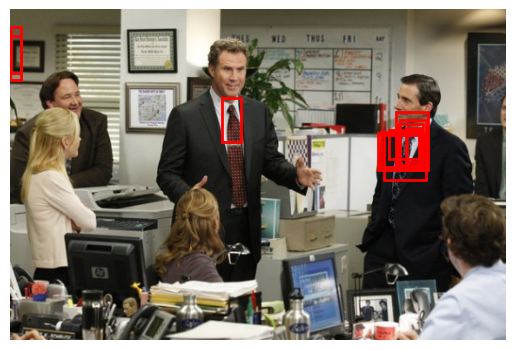

In [30]:
plot_image_with_boxes(img[0].transpose(1,2,0), pose_boxes.T)

torch.Size([1, 4, 44])
5


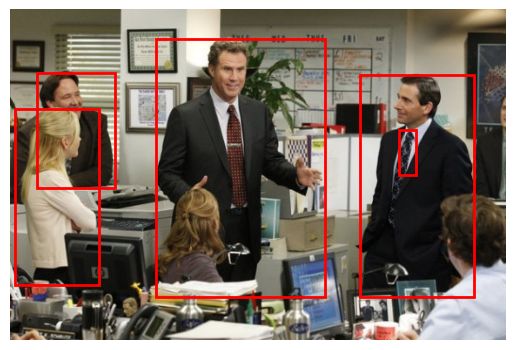

In [356]:
print(yolo_boxes.shape)
print(len(keep_indices))
plot_image_with_boxes(img[0].transpose(1,2,0), filtered_boxes.T.detach().numpy())

In [314]:
def draw_normalized_boxes( image, boxes, color=(0, 255, 0), thickness=2):
    """
    Draws bounding boxes (xywh, normalized) on the image.

    Args:
        image: np.ndarray, shape (H, W, 3)
        boxes: np.ndarray or list, shape (N, 4) or (4,) -- each box is [x, y, w, h] normalized (0-1)
        color: tuple, box color (B, G, R)
        thickness: int, line thickness

    Returns:
        image_out: np.ndarray, image with boxes drawn
    """
    img = image.copy()
    img = img[0]
    img = img
    print(img.shape)
    h, w = img.shape[1:]
    boxes = np.array(boxes)
    if boxes.ndim == 1:
        boxes = boxes[None, :]
    for box in boxes:
        x1, y1, x2, y2 = box
        # Convert normalized xywh to pixel coordinates
        x1 = int(x1 )
        y1 = int((y1) )
        x2 = int((x2 ) )
        y2 = int((y2 ) )
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    return img

In [238]:
yolo_boxes.shape

torch.Size([1, 4, 54])

In [189]:
boxes_img = draw_normalized_boxes((img*0.5 + 0.5).detach().numpy(), yolo_boxes.T.detach().numpy())

(3, 380, 570)


In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
def plot_image_with_boxes(image, boxes, labels=None, color='red', linewidth=2):
    """
    Plots an image and draws bounding boxes on it.

    Args:
        image (np.ndarray): The image as a NumPy array.
        boxes (list or np.ndarray): A list of bounding boxes, where each box is
                                    in the format [x_min, y_min, x_max, y_max].
        labels (list, optional): A list of labels for each bounding box.
        color (str): The color of the bounding box outlines.
        linewidth (int): The thickness of the bounding box lines.
    """
    # Create figure and axes
    fig, ax = plt.subplots(1)

    # Display the image
    ax.imshow(image)

    # Check if a single box was passed and wrap it in a list
    if not isinstance(boxes[0], (list, np.ndarray)):
        boxes = [boxes]

    # Iterate over each bounding box
    for i, box in enumerate(boxes):
        x_c, y_c, w, h = box
        x_min = x_c - w/2
        y_min = y_c - h/2        
        # Calculate the width and height of the box
        # width = x_max - x_min
        # height = y_max - y_min
        
        # Create a Rectangle patch
        rect = patches.Rectangle(
            (x_min, y_min), w, h,
            linewidth=linewidth, edgecolor=color, facecolor='none'
        )

        # Add the patch to the Axes
        ax.add_patch(rect)

        # Add a label if provided
        if labels and len(labels) > i:
            ax.text(
                x_min, y_min - 5, labels[i],
                color=color, fontsize=12,
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
            )

    # Turn off the axis to show only the image
    ax.axis('off')
    
    # Display the plot
    plt.show()

In [191]:
import matplotlib.pyplot as plt

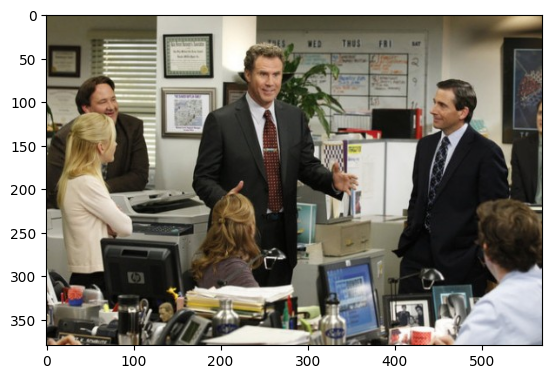

In [192]:
plt.imshow(boxes_img.transpose(1,2,0))

In [62]:
mask = max_values > 0.6
print(torch.sum(mask))

tensor(13)


In [ ]:
final_out[0].shape

torch.Size([1, 84, 4536])

In [35]:
seed[10].shape

torch.Size([1, 256, 20, 20])

In [37]:
final_out[0].shape

torch.Size([1, 84, 8400])

In [81]:
features['model.16.cv2'].shape

torch.Size([1, 64, 80, 80])

In [39]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [84]:
print(len(output))
print(output[0].shape)

1
torch.Size([64, 80, 80])


In [195]:
det = YOLO("../checkpoints/yolo11n.pt")
pose = YOLO("../checkpoints/yolo11n-pose.pt")


In [199]:
det = det.to(device)
pose = pose.to(device)

In [193]:
device = torch.device('cuda')
rand_input = torch.rand(1,3,640,640).to(device)

In [196]:
backbone1 = det.model
backbone1.model = det.model.model[:12]

In [ ]:
r1 = backbone1(rand_input)

Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [134]:
mods = dict(model.named_modules())

In [150]:
mods[''].model[6].cv2

Conv(
  (conv): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
  (act): SiLU(inplace=True)
)

In [91]:
b11 = pose.model.model[:12]
r11 = b11(rand_input)

In [109]:
backbone1 = backbone1.eval()

In [157]:
target = det.model.get_submodule("model.6.cv2.act")

In [155]:
probe = {}
handle = backbone1.model[6].cv1.conv.register_forward_hook(
    lambda m, i, o: probe.setdefault("x", o.detach())
)

In [154]:
backbone1.model[6].cv1

Conv(
  (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
  (act): SiLU(inplace=True)
)

In [98]:
det.model.model[:12]

Sequential(
  (0): Conv(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
  )
  (2): C3k2(
    (cv1): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
          (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
      )
    )
  )
  (3): Conv(
    (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (act): SiLU(inplace=True)
  )
 

In [97]:
pose.model.model[12:15]

Sequential(
  (12): Concat()
  (13): C3k2(
    (cv1): Conv(
      (conv): Conv2d(384, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
          (conv): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_runni

In [89]:
r11.shape

torch.Size([1, 256, 40, 40])

In [3]:
det_model = det.model
pose_model = pose.model

In [11]:
import torch
import torch.nn as nn

def print_model_flow(model, input_size=(1, 3, 224, 224)):
    """
    Prints the flow of layers in a PyTorch model, showing input-output connections.
    
    Args:
        model (nn.Module): The PyTorch model whose flow is to be printed.
        input_size (tuple): The shape of the dummy input tensor to run the model.
    """
    def forward_hook(module, input, output):
        """
        Hook function to print the layer's input and output shapes.
        """
        input_shape = [str(x.shape) for x in input]
        output_shape = str(output.shape)
        print(f'{module.__class__.__name__.ljust(20)} | Input shape: {", ".join(input_shape):<40} | Output shape: {output_shape}')
    
    # Register forward hooks for each layer in the model
    hooks = []
    for layer in model.children():
        hook = layer.register_forward_hook(forward_hook)
        hooks.append(hook)
    
    # Create dummy input with the specified shape
    dummy_input = torch.randn(*input_size)
    
    print(f"{'Layer Name'.ljust(20)} | {'Input Shape':<40} | Output Shape")
    print("=" * 80)

    try:
        # Run a forward pass through the model to trigger the hooks
        model(dummy_input)  
    except Exception as e:
        print(f"Error during forward pass: {e}")
    
    # Remove hooks after use
    for hook in hooks:
        hook.remove()

# Example usage
# Assuming `model` is your PyTorch model
# print_model_flow(model)


In [201]:
class YOLOWithFeatureRouting(nn.Module):
    def __init__(self, model_path, head_layers=16):
        super().__init__()
        
        self.yolo = YOLO(model_path)
        self.model_layers = self.yolo.model.model
        self.head_layers = head_layers
        
        # Split layers
        self.head = nn.ModuleList(self.model_layers[:head_layers + 1])
        self.tail = nn.ModuleList(self.model_layers[head_layers + 1:])
        
    def forward_with_routing(self, x, extract_at_layers=None, inject_at_layers=None):
        """
        Forward pass with explicit feature routing
        
        Args:
            x: Input tensor
            extract_at_layers: List of layer indices to extract features from
            inject_at_layers: Dict of {layer_idx: feature_tensor} to inject features
        
        Returns:
            output, extracted_features
        """
        if extract_at_layers is None:
            extract_at_layers = [10, 13, 16]
        if inject_at_layers is None:
            inject_at_layers = {}
        
        extracted_features = {}
        
        # Forward through head
        for i, layer in enumerate(self.head):
            x = layer(x)
            
            # Extract features if needed
            if i in extract_at_layers:
                extracted_features[f'layer_{i}'] = x.detach()
        
        head_output = x
        
        # Forward through tail
        for i, layer in enumerate(self.tail):
            tail_idx = self.head_layers + 1 + i
            
            # Inject features if specified
            if tail_idx in inject_at_layers:
                injected_feature = inject_at_layers[tail_idx]
                # Implement your feature combination logic here
                # For example: x = torch.cat([x, injected_feature], dim=1)
                # or x = x + injected_feature, depending on your needs
            
            x = layer(x)
        
        return x, extracted_features, head_output

In [202]:
model2 = YOLOWithFeatureRouting("../checkpoints/yolo11n.pt", head_layers=16)

output2, features2, head_out2 = model2.forward_with_routing(
    x, 
    extract_at_layers=[10, 13, 16],
    inject_at_layers={}  # Add injection logic as needed
)

print("Method 2 - Extracted features:", list(features2.keys()))
print("Method 2 - Output shape:", output2.shape if hasattr(output2, 'shape') else type(output2))

TypeError: cat() received an invalid combination of arguments - got (Tensor, int), but expected one of:
 * (tuple of Tensors tensors, int dim = 0, *, Tensor out = None)
 * (tuple of Tensors tensors, name dim, *, Tensor out = None)
